# EEG Channel Selection Analysis

This notebook analyzes the results from `CNN_score_EEG_filter_fr.py`, which implements a two-phase channel selection approach:

**Phase 1**: Train with all 60 EEG channels using channel-wise attention to identify the most predictive channels.

**Phase 2**: Retrain using only the top-K most important channels to validate their sufficiency.

## Goals
1. Identify which EEG channels are most predictive of team performance
2. Visualize channel importance patterns
3. Compare Phase 1 (full) vs Phase 2 (reduced) model performance
4. Analyze learning dynamics and convergence

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Directory setup
LOG_DIR = Path("training_logs")

# Find the most recent logs (or specify manually)
phase1_files = sorted(LOG_DIR.glob("phase1_5fold_EEG_filter_fr_*.csv"))
phase2_files = sorted(LOG_DIR.glob("phase2_topk_EEG_filter_fr_*.csv"))

if not phase1_files or not phase2_files:
    print("ERROR: No training logs found. Run CNN_score_EEG_filter_fr.py first.")
else:
    # Use the most recent files
    PHASE1_LOG = phase1_files[-1]
    PHASE2_LOG = phase2_files[-1]
    record_num = str(PHASE1_LOG)[-19:-4]
    CH_IMPORTANCE = LOG_DIR / str(f"channel_importance_{record_num}.npy")
    TOP_K_INDICES = LOG_DIR / str(f"top_k_indices_{record_num}.npy")
    
    print(f"Phase 1 Log: {PHASE1_LOG.name}")
    print(f"Phase 2 Log: {PHASE2_LOG.name}")
    print(f"Channel Importance: {CH_IMPORTANCE.name}")
    print(f"Top-K Indices: {TOP_K_INDICES.name}")

Phase 1 Log: phase1_5fold_EEG_filter_fr_20260326_143132.csv
Phase 2 Log: phase2_topk_EEG_filter_fr_20260326_143132.csv
Channel Importance: channel_importance_20260326_143132.npy
Top-K Indices: top_k_indices_20260326_143132.npy


In [56]:
record_num

'20260326_143132'

In [57]:
def load_clean_log(path):
    """Load CSV log, skipping comment lines and handling headers."""
    # Read the file and find where the actual data starts
    with open(path, 'r') as f:
        lines = f.readlines()
    
    # Find the first line that's not a comment and contains 'Epoch'
    header_idx = None
    for i, line in enumerate(lines):
        if not line.startswith('#') and 'Epoch' in line:
            header_idx = i
            break
    
    if header_idx is None:
        raise ValueError(f"Could not find data header in {path}")
    
    # Read CSV starting from the header
    df = pd.read_csv(path, skiprows=header_idx)
    
    # Remove any remaining comment rows or summary rows
    df = df[~df.iloc[:, 0].astype(str).str.startswith('#')]
    
    # Convert Epoch to numeric and filter
    df['Epoch'] = pd.to_numeric(df['Epoch'], errors='coerce')
    df = df.dropna(subset=['Epoch'])
    
    # Convert numeric columns
    numeric_cols = ['Train_MSE', 'Val_MSE', 'Val_RMSE', 'Val_MAE', 'Val_R2', 'Fold', 'Total_Params', 'Trainable_Params']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Remove any rows where Fold is NaN (summary rows)
    df = df.dropna(subset=['Fold'])
    
    df['Epoch'] = df['Epoch'].astype(int)
    df['Fold'] = df['Fold'].astype(int)
    
    return df

# Load data
df_phase1 = load_clean_log(PHASE1_LOG)
df_phase2 = load_clean_log(PHASE2_LOG)
importance = np.load(CH_IMPORTANCE)
top_k = np.load(TOP_K_INDICES)

print(f"\nPhase 1: {len(df_phase1)} training records across {df_phase1['Fold'].nunique()} folds")
print(f"Phase 2: {len(df_phase2)} training records across {df_phase2['Fold'].nunique()} folds")
print(f"Total EEG channels: {len(importance)}")
print(f"Top-K selected: {len(top_k)} channels")
print(f"\nTop-K channel indices: {sorted(top_k.tolist())}")

FileNotFoundError: [Errno 2] No such file or directory: 'training_logs/channel_importance_20260326_143132.npy'

## 2. Channel Importance Analysis

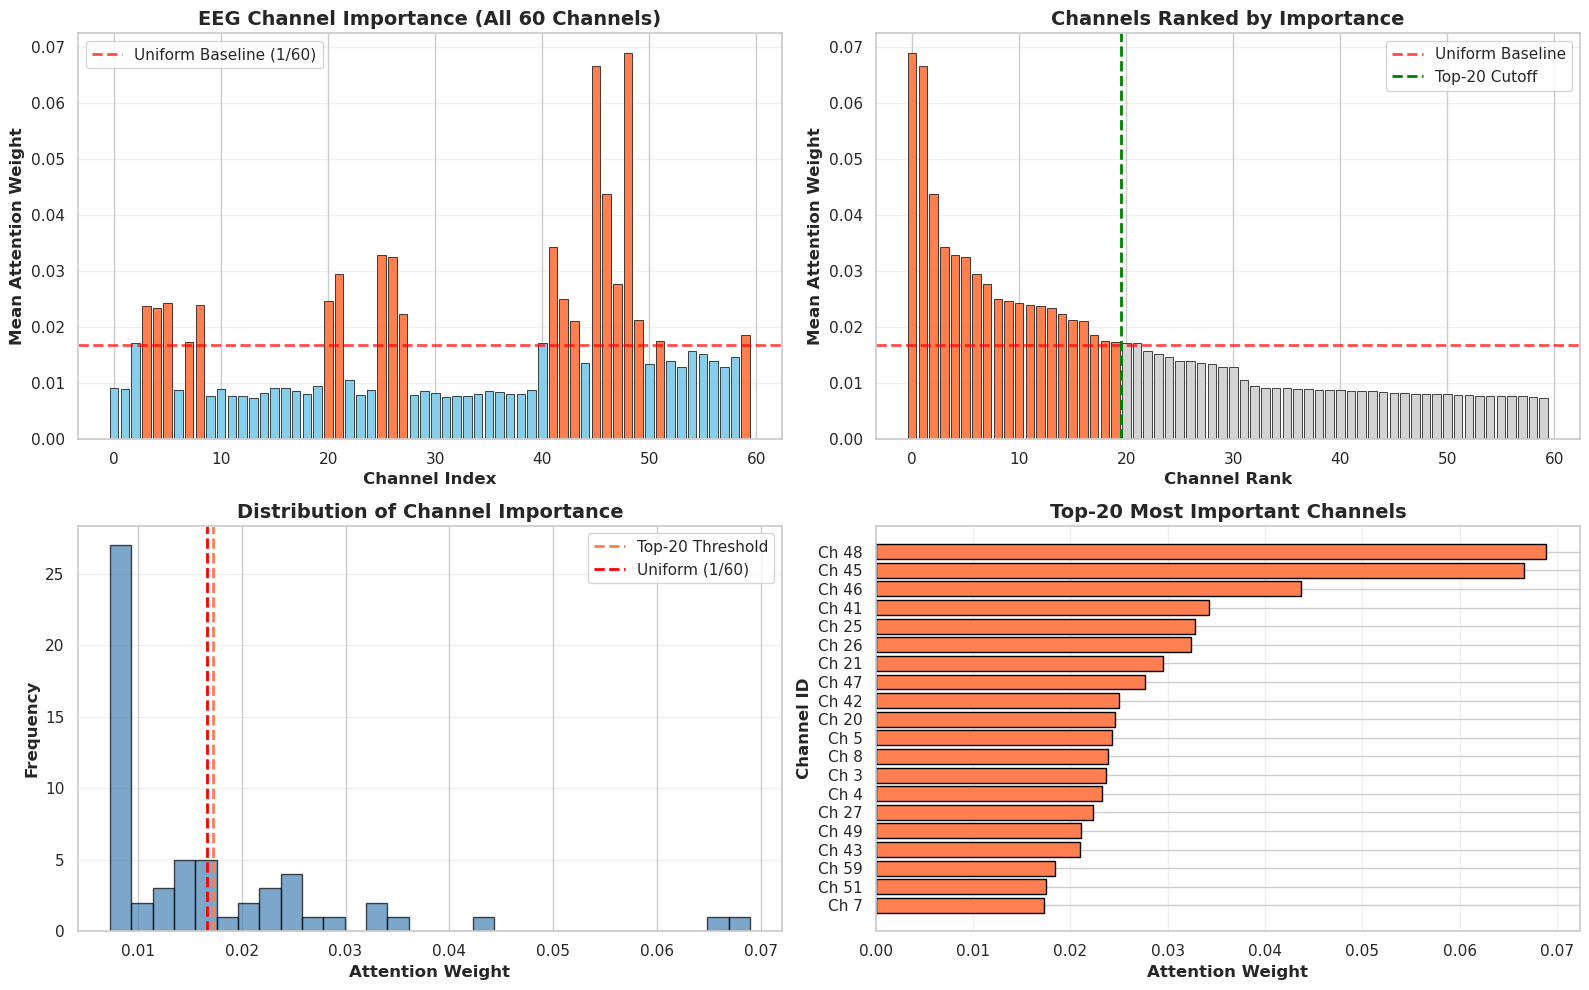


📊 Channel Importance Statistics:
   Mean importance: 0.016667
   Std deviation:   0.012620
   Min importance:  0.007326 (Channel 13)
   Max importance:  0.068922 (Channel 48)
   Top-20 threshold: 0.017234


In [ ]:
# Create comprehensive channel importance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Bar chart of all channels with top-K highlighted
ax1 = axes[0, 0]
colors = ['coral' if i in top_k else 'skyblue' for i in range(len(importance))]
ax1.bar(range(len(importance)), importance, color=colors, edgecolor='black', linewidth=0.5)
ax1.axhline(y=1/60, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Uniform Baseline (1/60)')
ax1.set_xlabel("Channel Index", fontsize=12, fontweight='bold')
ax1.set_ylabel("Mean Attention Weight", fontsize=12, fontweight='bold')
ax1.set_title("EEG Channel Importance (All 60 Channels)", fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Sorted importance (descending)
ax2 = axes[0, 1]
sorted_idx = np.argsort(-importance)
sorted_imp = importance[sorted_idx]
colors_sorted = ['coral' if i < len(top_k) else 'lightgray' for i in range(len(importance))]
ax2.bar(range(len(importance)), sorted_imp, color=colors_sorted, edgecolor='black', linewidth=0.5)
ax2.axhline(y=1/60, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Uniform Baseline')
ax2.axvline(x=len(top_k)-0.5, color='green', linestyle='--', linewidth=2, label=f'Top-{len(top_k)} Cutoff')
ax2.set_xlabel("Channel Rank", fontsize=12, fontweight='bold')
ax2.set_ylabel("Mean Attention Weight", fontsize=12, fontweight='bold')
ax2.set_title("Channels Ranked by Importance", fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Distribution of importance scores
ax3 = axes[1, 0]
ax3.hist(importance, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=importance[top_k].min(), color='coral', linestyle='--', linewidth=2, label=f'Top-{len(top_k)} Threshold')
ax3.axvline(x=1/60, color='red', linestyle='--', linewidth=2, label='Uniform (1/60)')
ax3.set_xlabel("Attention Weight", fontsize=12, fontweight='bold')
ax3.set_ylabel("Frequency", fontsize=12, fontweight='bold')
ax3.set_title("Distribution of Channel Importance", fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Top-K channels detailed view
ax4 = axes[1, 1]
top_k_sorted = top_k[np.argsort(-importance[top_k])]
top_k_imp = importance[top_k_sorted]
ax4.barh(range(len(top_k)), top_k_imp, color='coral', edgecolor='black')
ax4.set_yticks(range(len(top_k)))
ax4.set_yticklabels([f'Ch {idx}' for idx in top_k_sorted])
ax4.set_xlabel("Attention Weight", fontsize=12, fontweight='bold')
ax4.set_ylabel("Channel ID", fontsize=12, fontweight='bold')
ax4.set_title(f"Top-{len(top_k)} Most Important Channels", fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(LOG_DIR / f'channel_importance_analysis_{record_num}.png', bbox_inches='tight')
plt.show()

print("\n📊 Channel Importance Statistics:")
print(f"   Mean importance: {importance.mean():.6f}")
print(f"   Std deviation:   {importance.std():.6f}")
print(f"   Min importance:  {importance.min():.6f} (Channel {importance.argmin()})")
print(f"   Max importance:  {importance.max():.6f} (Channel {importance.argmax()})")
print(f"   Top-{len(top_k)} threshold: {importance[top_k].min():.6f}")

In [ ]:
# Create a detailed table of top channels
channel_summary = pd.DataFrame({
    'Channel_ID': range(60),
    'Importance': importance,
    'Rank': np.argsort(-importance),
    'Selected': ['✓' if i in top_k else '' for i in range(60)]
})

channel_summary = channel_summary.sort_values('Importance', ascending=False).reset_index(drop=True)
channel_summary['Rank'] = range(1, 61)

print("\n📋 Top 20 Most Important EEG Channels:")
print(channel_summary.head(20).to_string(index=False))

# Save full table
channel_summary.to_csv(LOG_DIR / Path(f'channel_importance_table_{record_num}.csv'), index=False)
print(f"\n💾 Full channel table saved to {LOG_DIR / 'channel_importance_table_'}{record_num}.csv")


📋 Top 20 Most Important EEG Channels:
 Channel_ID  Importance  Rank Selected
         48    0.068922     1        ✓
         45    0.066623     2        ✓
         46    0.043680     3        ✓
         41    0.034189     4        ✓
         25    0.032764     5        ✓
         26    0.032376     6        ✓
         21    0.029492     7        ✓
         47    0.027682     8        ✓
         42    0.024959     9        ✓
         20    0.024587    10        ✓
          5    0.024236    11        ✓
          8    0.023884    12        ✓
          3    0.023701    13        ✓
          4    0.023265    14        ✓
         27    0.022331    15        ✓
         49    0.021108    16        ✓
         43    0.020975    17        ✓
         59    0.018442    18        ✓
         51    0.017451    19        ✓
          7    0.017234    20        ✓

💾 Full channel table saved to training_logs/channel_importance_table_20260326_152121.csv


## 3. Learning Curves: Phase 1 vs Phase 2

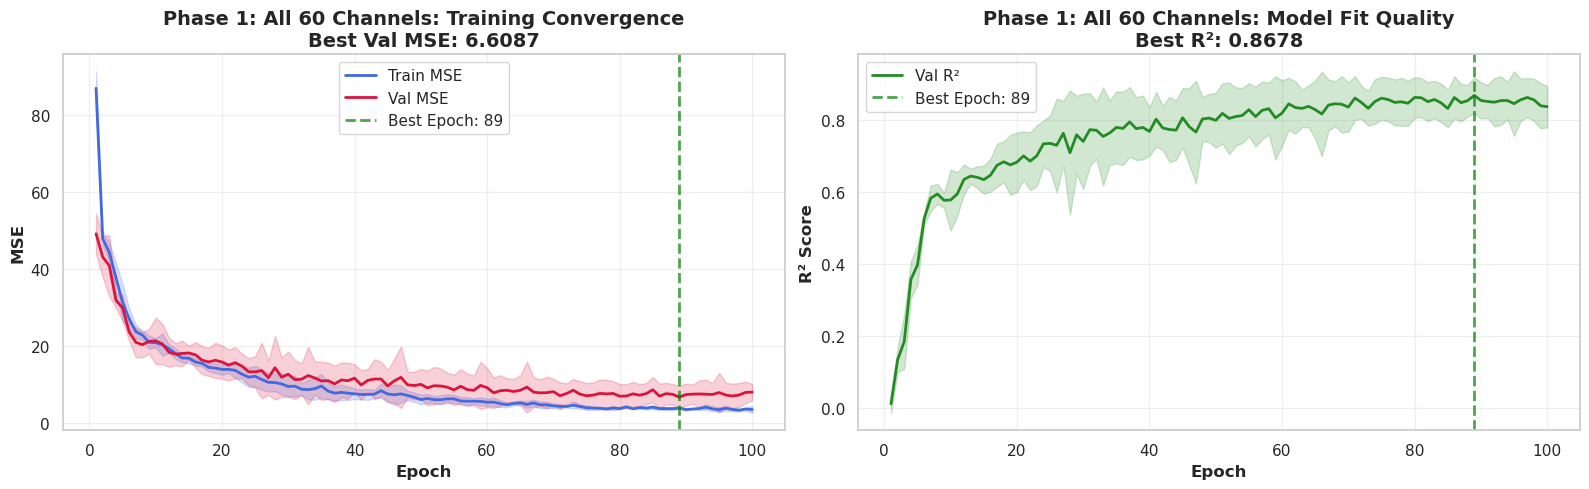

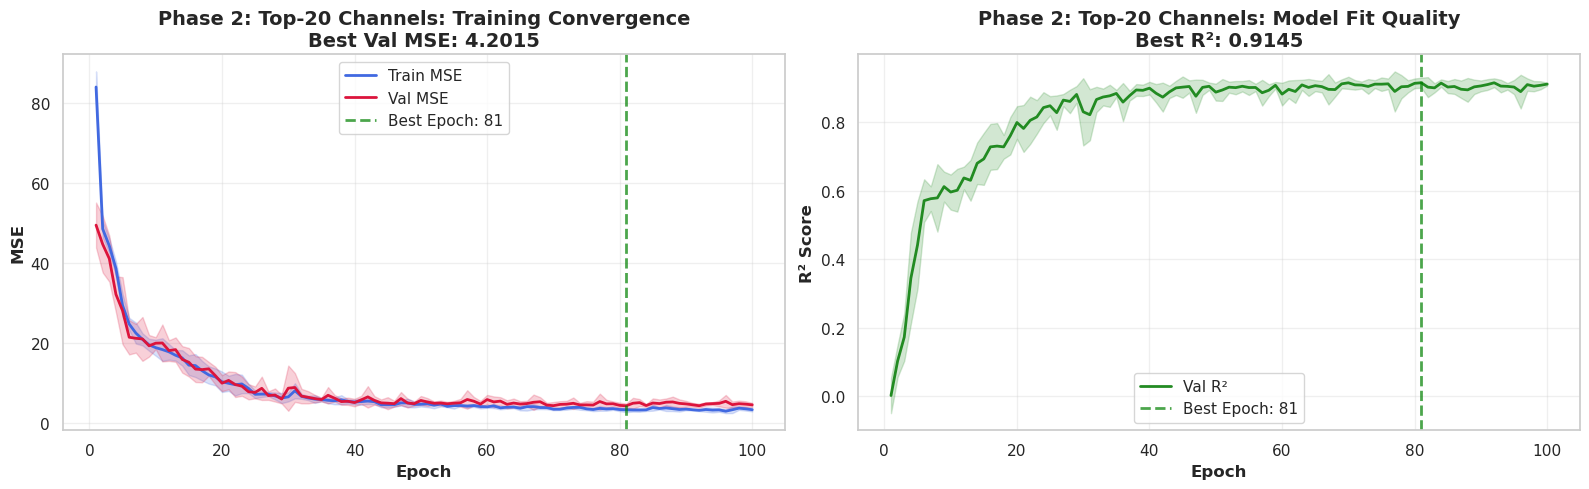

In [ ]:
def plot_learning_curves(df, phase_name, color_train='royalblue', color_val='crimson'):
    """Plot training and validation curves averaged across folds."""
    avg_df = df.groupby('Epoch').agg({
        'Train_MSE': ['mean', 'std'],
        'Val_MSE': ['mean', 'std'],
        'Val_R2': ['mean', 'std']
    }).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot MSE
    ax1 = axes[0]
    epochs = avg_df['Epoch']
    
    # Training MSE
    train_mean = avg_df[('Train_MSE', 'mean')]
    train_std = avg_df[('Train_MSE', 'std')]
    ax1.plot(epochs, train_mean, color=color_train, linewidth=2, label='Train MSE')
    ax1.fill_between(epochs, train_mean - train_std, train_mean + train_std, 
                      color=color_train, alpha=0.2)
    
    # Validation MSE
    val_mean = avg_df[('Val_MSE', 'mean')]
    val_std = avg_df[('Val_MSE', 'std')]
    ax1.plot(epochs, val_mean, color=color_val, linewidth=2, label='Val MSE')
    ax1.fill_between(epochs, val_mean - val_std, val_mean + val_std, 
                      color=color_val, alpha=0.2)
    
    # Mark best epoch
    best_epoch = val_mean.idxmin()
    best_val_mse = val_mean[best_epoch]
    ax1.axvline(x=epochs.iloc[best_epoch], color='green', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Best Epoch: {epochs.iloc[best_epoch]}')
    
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
    ax1.set_title(f'{phase_name}: Training Convergence\nBest Val MSE: {best_val_mse:.4f}', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot R²
    ax2 = axes[1]
    r2_mean = avg_df[('Val_R2', 'mean')]
    r2_std = avg_df[('Val_R2', 'std')]
    ax2.plot(epochs, r2_mean, color='forestgreen', linewidth=2, label='Val R²')
    ax2.fill_between(epochs, r2_mean - r2_std, r2_mean + r2_std, 
                      color='forestgreen', alpha=0.2)
    
    best_r2_epoch = r2_mean.idxmax()
    best_r2 = r2_mean[best_r2_epoch]
    ax2.axvline(x=epochs.iloc[best_r2_epoch], color='green', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Best Epoch: {epochs.iloc[best_r2_epoch]}')
    
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax2.set_title(f'{phase_name}: Model Fit Quality\nBest R²: {best_r2:.4f}', 
                  fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot Phase 1
fig1 = plot_learning_curves(df_phase1, f"Phase 1: All 60 Channels")
plt.savefig(LOG_DIR / f'phase1_learning_curves_{record_num}.png', bbox_inches='tight')
plt.show()

# Plot Phase 2
fig2 = plot_learning_curves(df_phase2, f"Phase 2: Top-{len(top_k)} Channels")
plt.savefig(LOG_DIR / f'phase2_learning_curves_{record_num}.png', bbox_inches='tight')
plt.show()

## 4. Direct Comparison: Phase 1 vs Phase 2


📊 Final Performance Comparison (Mean across 5 folds):
          Phase 1 (60 Ch)  Phase 2 (20 Ch)  Difference  % Change
Val_MSE            7.9165           4.4347     -3.4818  -43.9815
Val_RMSE           2.7936           2.1032     -0.6904  -24.7124
Val_MAE            1.9461           1.4115     -0.5346  -27.4708
Val_R2             0.8365           0.9106      0.0741    8.8557


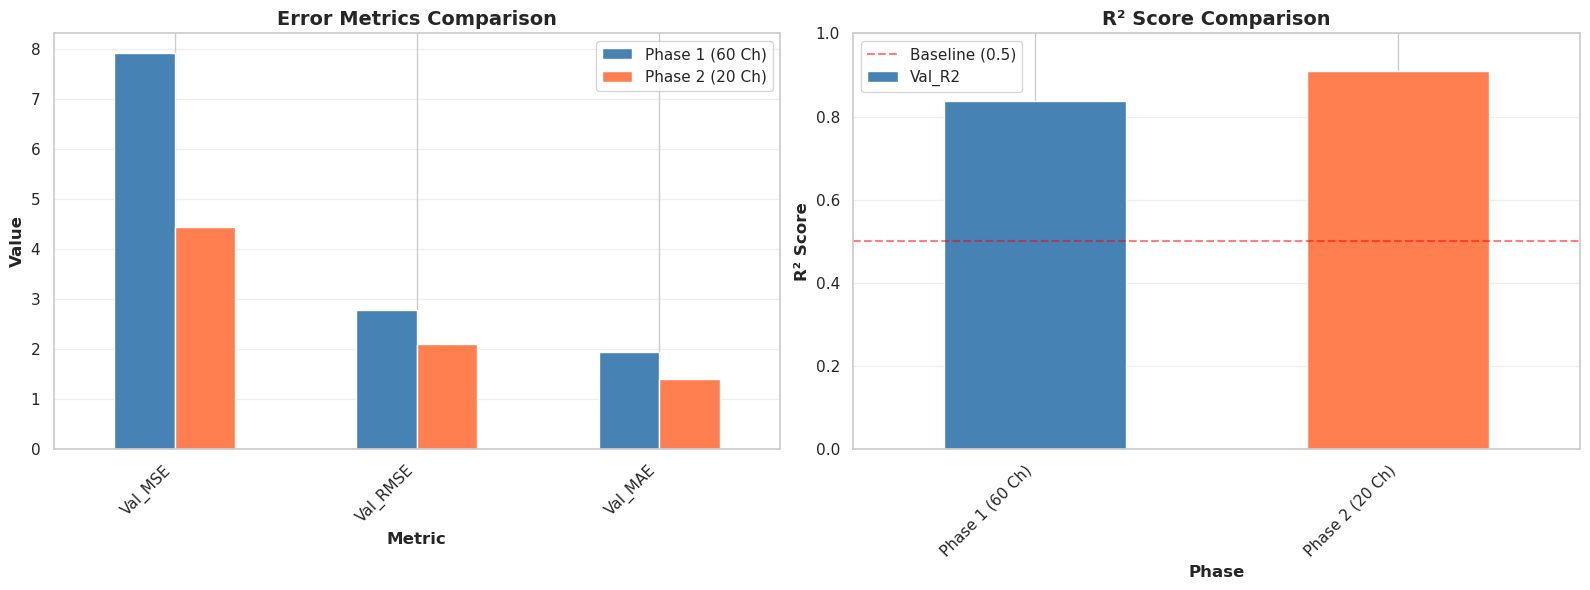


🔬 Paired t-test (Val MSE): t=3.1866, p=0.0333
   ✓ Significant difference between phases (p < 0.05)


In [ ]:
# Compare final epoch performance
def get_final_metrics(df):
    """Get the last epoch metrics for each fold."""
    final_df = df.sort_values(['Fold', 'Epoch']).groupby('Fold').tail(1)
    return final_df[['Val_MSE', 'Val_RMSE', 'Val_MAE', 'Val_R2']]

final_phase1 = get_final_metrics(df_phase1)
final_phase2 = get_final_metrics(df_phase2)

comparison = pd.DataFrame({
    f'Phase 1 (60 Ch)': final_phase1.mean(),
    f'Phase 2 ({len(top_k)} Ch)': final_phase2.mean(),
    'Difference': final_phase2.mean() - final_phase1.mean(),
    '% Change': ((final_phase2.mean() - final_phase1.mean()) / final_phase1.mean() * 100)
})

print("\n📊 Final Performance Comparison (Mean across 5 folds):")
print(comparison.round(4).to_string())

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error metrics
ax1 = axes[0]
error_metrics = comparison.loc[['Val_MSE', 'Val_RMSE', 'Val_MAE']]
error_metrics[[f'Phase 1 (60 Ch)', f'Phase 2 ({len(top_k)} Ch)']].plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title('Error Metrics Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
ax1.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# R² score
ax2 = axes[1]
r2_data = comparison.loc['Val_R2', [f'Phase 1 (60 Ch)', f'Phase 2 ({len(top_k)} Ch)']]
r2_data.plot(kind='bar', ax=ax2, color=['steelblue', 'coral'])
ax2.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Phase', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(LOG_DIR / f'phase_comparison_{record_num}.png', bbox_inches='tight')
plt.show()

# Statistical significance
from scipy import stats
t_stat, p_value = stats.ttest_rel(final_phase1['Val_MSE'], final_phase2['Val_MSE'])
print(f"\n🔬 Paired t-test (Val MSE): t={t_stat:.4f}, p={p_value:.4f}")
if p_value < 0.05:
    print("   ✓ Significant difference between phases (p < 0.05)")
else:
    print("   ✗ No significant difference (p >= 0.05)")

## 5. Per-Fold Analysis

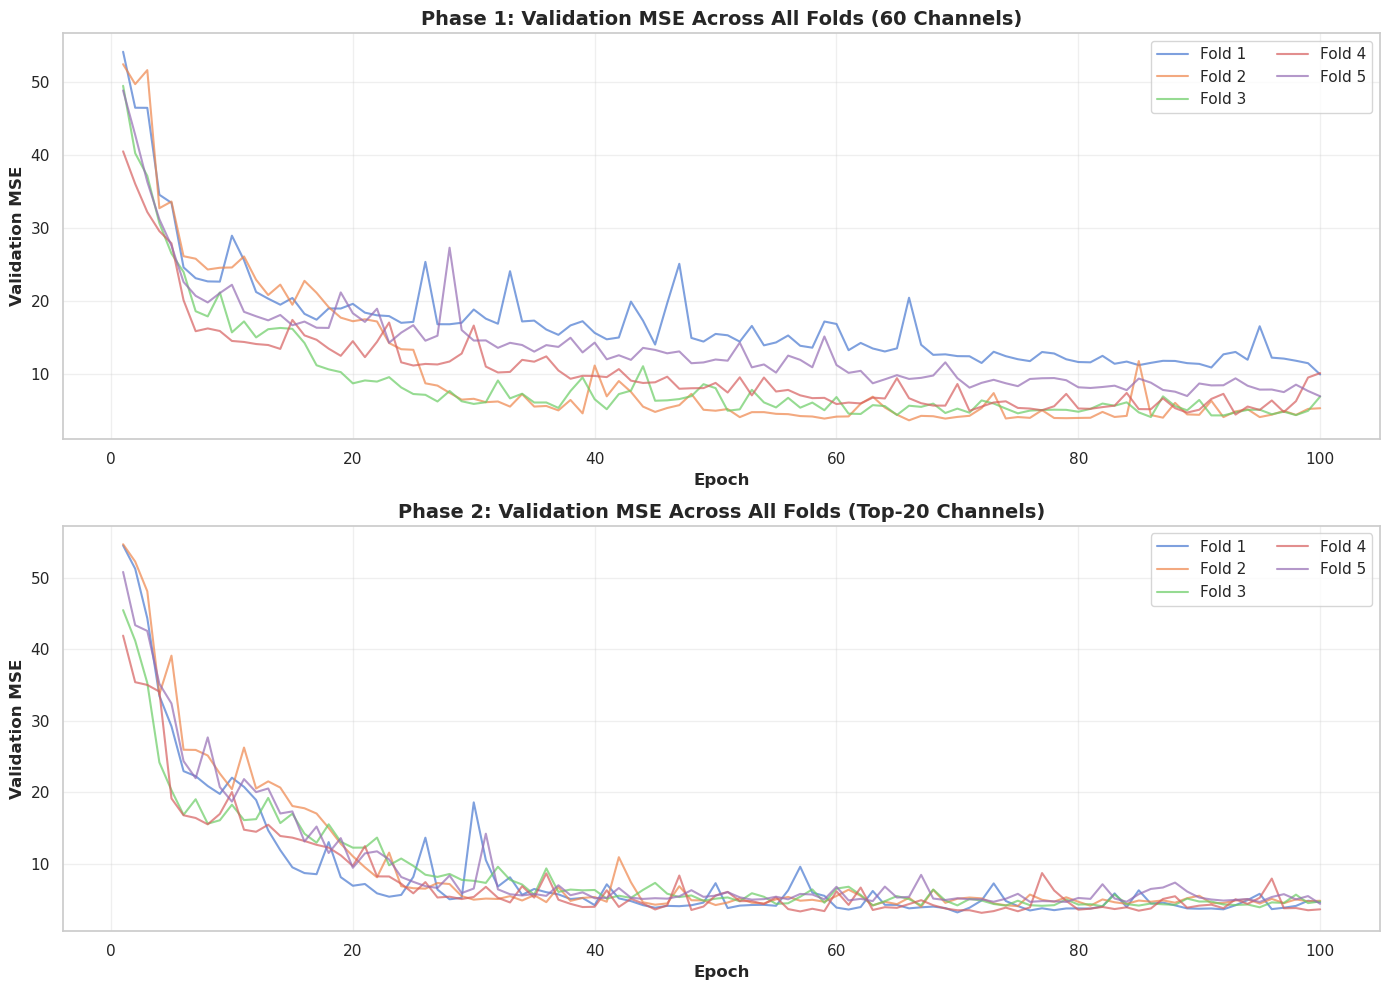

In [ ]:
# Visualize all folds together
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Phase 1: All folds
ax1 = axes[0]
for fold in sorted(df_phase1['Fold'].unique()):
    fold_df = df_phase1[df_phase1['Fold'] == fold]
    ax1.plot(fold_df['Epoch'], fold_df['Val_MSE'], label=f'Fold {fold}', alpha=0.7, linewidth=1.5)
ax1.set_title('Phase 1: Validation MSE Across All Folds (60 Channels)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Validation MSE', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', ncol=2)
ax1.grid(alpha=0.3)

# Phase 2: All folds
ax2 = axes[1]
for fold in sorted(df_phase2['Fold'].unique()):
    fold_df = df_phase2[df_phase2['Fold'] == fold]
    ax2.plot(fold_df['Epoch'], fold_df['Val_MSE'], label=f'Fold {fold}', alpha=0.7, linewidth=1.5)
ax2.set_title(f'Phase 2: Validation MSE Across All Folds (Top-{len(top_k)} Channels)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Validation MSE', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', ncol=2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / f'per_fold_convergence_{record_num}.png', bbox_inches='tight')
plt.show()

## 6. Model Efficiency Analysis


⚙️ Model Efficiency Analysis:
          Phase  Total_Parameters  Val_R2  Efficiency_Score
Phase 1 (60 Ch)          606594.0 0.83652          1.379044
Phase 2 (20 Ch)          606594.0 0.91060          1.501169

   Parameter reduction: 0.00%
   Performance change: 8.86%
   Efficiency gain: 8.86%


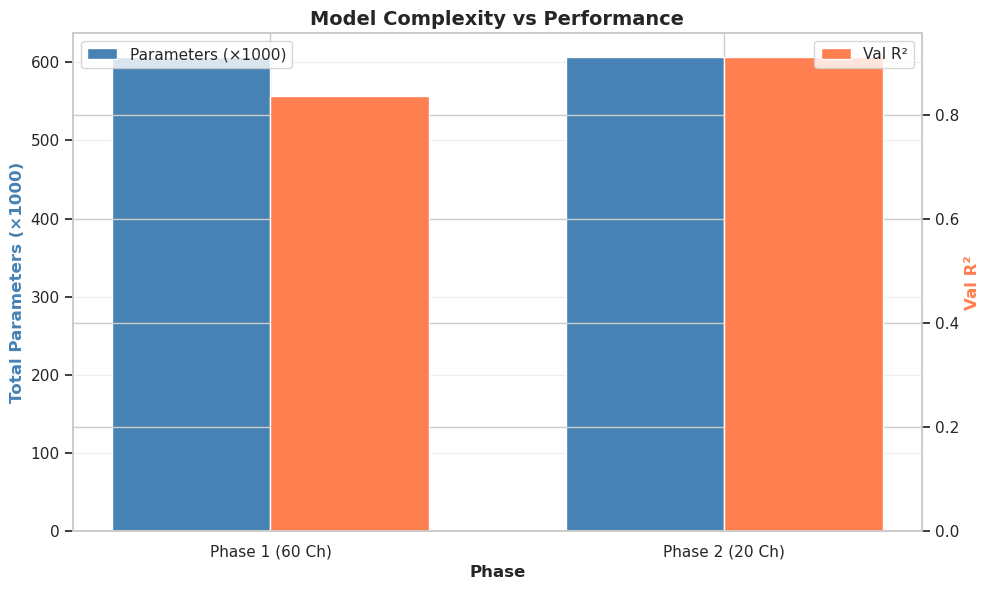

In [ ]:
# Extract model parameters
params_phase1 = df_phase1['Total_Params'].iloc[0]
params_phase2 = df_phase2['Total_Params'].iloc[0]

# Performance vs complexity
perf_phase1 = final_phase1['Val_R2'].mean()
perf_phase2 = final_phase2['Val_R2'].mean()

efficiency = pd.DataFrame({
    'Phase': ['Phase 1 (60 Ch)', f'Phase 2 ({len(top_k)} Ch)'],
    'Total_Parameters': [params_phase1, params_phase2],
    'Val_R2': [perf_phase1, perf_phase2],
    'Efficiency_Score': [perf_phase1 / params_phase1 * 1e6, perf_phase2 / params_phase2 * 1e6]
})

print("\n⚙️ Model Efficiency Analysis:")
print(efficiency.to_string(index=False))
print(f"\n   Parameter reduction: {(1 - params_phase2/params_phase1)*100:.2f}%")
print(f"   Performance change: {(perf_phase2/perf_phase1 - 1)*100:.2f}%")
print(f"   Efficiency gain: {(efficiency.iloc[1]['Efficiency_Score']/efficiency.iloc[0]['Efficiency_Score'] - 1)*100:.2f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(efficiency))
width = 0.35

ax.bar(x - width/2, efficiency['Total_Parameters']/1000, width, label='Parameters (×1000)', color='steelblue')
ax2 = ax.twinx()
ax2.bar(x + width/2, efficiency['Val_R2'], width, label='Val R²', color='coral')

ax.set_xlabel('Phase', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Parameters (×1000)', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Val R²', fontsize=12, fontweight='bold', color='coral')
ax.set_title('Model Complexity vs Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(efficiency['Phase'])
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / f'efficiency_analysis_{record_num}.png', bbox_inches='tight')
plt.show()

## 7. Summary and Conclusions

In [ ]:
print("="*80)
print("\n🎯 EEG CHANNEL SELECTION: KEY FINDINGS\n")
print("="*80)

print(f"\n1. CHANNEL SELECTION")
print(f"   • Total channels: 60")
print(f"   • Selected channels: {len(top_k)}")
print(f"   • Reduction: {(1 - len(top_k)/60)*100:.1f}%")
print(f"   • Top 5 channels: {sorted(top_k[np.argsort(-importance[top_k])[:5]].tolist())}")

print(f"\n2. PERFORMANCE COMPARISON (Final Epoch, Mean ± SD)")
print(f"   Phase 1 (60 channels):")
print(f"   • Val MSE:  {final_phase1['Val_MSE'].mean():.4f} ± {final_phase1['Val_MSE'].std():.4f}")
print(f"   • Val RMSE: {final_phase1['Val_RMSE'].mean():.4f} ± {final_phase1['Val_RMSE'].std():.4f}")
print(f"   • Val MAE:  {final_phase1['Val_MAE'].mean():.4f} ± {final_phase1['Val_MAE'].std():.4f}")
print(f"   • Val R²:   {final_phase1['Val_R2'].mean():.4f} ± {final_phase1['Val_R2'].std():.4f}")

print(f"\n   Phase 2 ({len(top_k)} channels):")
print(f"   • Val MSE:  {final_phase2['Val_MSE'].mean():.4f} ± {final_phase2['Val_MSE'].std():.4f}")
print(f"   • Val RMSE: {final_phase2['Val_RMSE'].mean():.4f} ± {final_phase2['Val_RMSE'].std():.4f}")
print(f"   • Val MAE:  {final_phase2['Val_MAE'].mean():.4f} ± {final_phase2['Val_MAE'].std():.4f}")
print(f"   • Val R²:   {final_phase2['Val_R2'].mean():.4f} ± {final_phase2['Val_R2'].std():.4f}")

print(f"\n3. MODEL EFFICIENCY")
print(f"   • Phase 1 parameters: {params_phase1:,}")
print(f"   • Phase 2 parameters: {params_phase2:,}")
print(f"   • Parameter reduction: {(1 - params_phase2/params_phase1)*100:.2f}%")
print(f"   • Performance/Complexity ratio improvement: {(efficiency.iloc[1]['Efficiency_Score']/efficiency.iloc[0]['Efficiency_Score'] - 1)*100:.2f}%")

print(f"\n4. INTERPRETATION")
r2_change = (final_phase2['Val_R2'].mean() - final_phase1['Val_R2'].mean()) / final_phase1['Val_R2'].mean() * 100
if abs(r2_change) < 5:
    print(f"   ✓ The top-{len(top_k)} channels maintain {100-abs(r2_change):.1f}% of full model performance")
    print(f"   ✓ This suggests these channels capture the essential predictive information")
    print(f"   ✓ Channel selection is successful - simpler model with comparable accuracy")
elif r2_change > 0:
    print(f"   ✓ The reduced model actually performs {r2_change:.1f}% BETTER")
    print(f"   ✓ This suggests the full model may have overfitted to noise in less important channels")
else:
    print(f"   ⚠ Performance decreased by {abs(r2_change):.1f}%")
    print(f"   ⚠ Consider increasing top-K or examining which channels were excluded")

print(f"\n5. RECOMMENDED NEXT STEPS")
print(f"   • Use the top-{len(top_k)} channels for final model training")
print(f"   • Investigate spatial/functional meaning of selected channels")
print(f"   • Consider ablation studies on individual top channels")
print(f"   • Validate findings with independent test set")

print("\n" + "="*80)
print(f"\n📁 All visualizations saved to: {LOG_DIR}/")
print("="*80)


🎯 EEG CHANNEL SELECTION: KEY FINDINGS


1. CHANNEL SELECTION
   • Total channels: 60
   • Selected channels: 20
   • Reduction: 66.7%
   • Top 5 channels: [25, 41, 45, 46, 48]

2. PERFORMANCE COMPARISON (Final Epoch, Mean ± SD)
   Phase 1 (60 channels):
   • Val MSE:  7.9165 ± 2.0972
   • Val RMSE: 2.7936 ± 0.3748
   • Val MAE:  1.9461 ± 0.3296
   • Val R²:   0.8365 ± 0.0574

   Phase 2 (20 channels):
   • Val MSE:  4.4347 ± 0.4820
   • Val RMSE: 2.1032 ± 0.1180
   • Val MAE:  1.4115 ± 0.0602
   • Val R²:   0.9106 ± 0.0041

3. MODEL EFFICIENCY
   • Phase 1 parameters: 606,594.0
   • Phase 2 parameters: 606,594
   • Parameter reduction: 0.00%
   • Performance/Complexity ratio improvement: 8.86%

4. INTERPRETATION
   ✓ The reduced model actually performs 8.9% BETTER
   ✓ This suggests the full model may have overfitted to noise in less important channels

5. RECOMMENDED NEXT STEPS
   • Use the top-20 channels for final model training
   • Investigate spatial/functional meaning of select

In [ ]:
# Generate summary report CSV
summary_report = pd.DataFrame({
    'Metric': ['Total Channels', 'Selected Channels', 'Phase 1 Val R²', 
               f'Phase 2 ({len(top_k)}Ch) Val R²', 'Performance Change (%)',
               'Phase 1 Parameters', 'Phase 2 Parameters', 'Parameter Reduction (%)'],
    'Value': [60, len(top_k), 
              f"{final_phase1['Val_R2'].mean():.4f}",
              f"{final_phase2['Val_R2'].mean():.4f}",
              f"{r2_change:.2f}",
              params_phase1, params_phase2,
              f"{(1 - params_phase2/params_phase1)*100:.2f}"]
})

summary_report.to_csv(LOG_DIR / f'analysis_summary_{record_num}.csv', index=False)
print(f"\n💾 Summary report saved to {LOG_DIR / 'analysis_summary.csv'}")


💾 Summary report saved to training_logs/analysis_summary.csv
